In [1]:

from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [ ]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

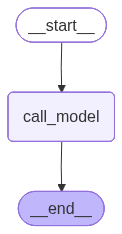

In [6]:
graph = builder.compile()
graph

In [7]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]})

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='88a14ed7-0552-4f3d-bc45-cae0db704825'),
  AIMessage(content='Hello Nitish! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DHo1ec8P3gWa7SadMkoAuscT6mNCw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd727-f15a-78f0-8199-c253c19b8237-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='32944a7f-cc14-42bb-9193-1692c4b09d12'),
  AIMessage(content='I am sorry, I do not have access to that information. But feel free to tell me your name!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 12, 'total_tokens': 34, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DHo1nSior1T2Ty1sBi5K33sHxdUmR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd728-14c5-7b40-87fc-6f33de8f311f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 22, 'total_tokens': 34, 'input_token_details'

In [9]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [11]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [12]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='dc474306-4578-4318-a0b3-e681213d7740'),
  AIMessage(content='Hello Nitish! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DHo2NpSsn5yO4zmV4hivBk8egM1Bd', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd728-a418-7400-bdce-f6ef5ce5b358-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [16]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='dc474306-4578-4318-a0b3-e681213d7740'),
  AIMessage(content='Hello Nitish! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DHo2NpSsn5yO4zmV4hivBk8egM1Bd', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd728-a418-7400-bdce-f6ef5ce5b358-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [17]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Nitish.
- AIMessage : Hello Nitish! How can I assist you today?
- HumanMessage : What is my name?
- AIMessage : Your name is Nitish.
